
# RQ2 Notebook — Tabular vs Graph-Based Learning for Social Bot Detection

This notebook implements **RQ2** from the revised proposal:

> **Do graph-based models provide statistically meaningful gains over strong tabular baselines when the graph is constructed from behavioral similarity rather than native social interactions?**

It is organized to go **step by step from data loading to the required RQ2 outputs**:

- **Figure RQ2-a**: comparative performance of strong tabular and graph-based models
- **Figure RQ2-b**: sensitivity of graph models to graph-construction choices
- **Table RQ2-a**: main model comparison table
- **Table RQ2-b**: statistical comparison across repeated seeds

It writes all RQ2 outputs into:

- `outputs/rq2_figures/` for figures
- `outputs/rq2_tables/` for tables

All figures are saved as **PDF** files in addition to PNG.

**Patched behavior:** this notebook tries to use **XGBoost** first and automatically falls back to
**HistGradientBoostingClassifier** if XGBoost is unavailable or broken in the local environment.


In [ ]:

# Optional dependency note:
# The graph sections require torch-geometric.
# If it is missing in your environment, install it first according to your PyTorch version:
#
# pip install torch-geometric
#
# The notebook is written so that the tabular RQ2 pipeline still runs without it.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from scipy.stats import wilcoxon

XGB_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.")
    print("Import error:", e)

# Optional graph imports
PYG_AVAILABLE = True
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv, GATConv
    from sklearn.neighbors import kneighbors_graph
except Exception as e:
    PYG_AVAILABLE = False
    print("torch-geometric is not available. Graph sections will be skipped until installed.")
    print("Import error:", e)

PRIMARY_SEED = 42
ROBUSTNESS_SEEDS = [42, 52, 62, 72, 82]

# Paths
DATA_PATH = Path("./Data/full_dataset.csv")
BASE_DIR = Path("")
OUT_DIR = BASE_DIR / "outputs"
RQ2_FIG_DIR = OUT_DIR / "rq2_figures"
RQ2_TABLE_DIR = OUT_DIR / "rq2_tables"
RQ2_FIG_DIR.mkdir(parents=True, exist_ok=True)
RQ2_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Feature policy
NUMERIC_FEATURES = [
    "followers_count", "friends_count", "statuses_count",
    "favourites_count", "listed_count"
]
BINARY_FEATURES = [
    "default_profile", "default_profile_image", "geo_enabled"
]
MISSINGNESS_FEATURES = [
    "default_profile_missing", "default_profile_image_missing", "geo_enabled_missing"
]
REVISED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + MISSINGNESS_FEATURES

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    if PYG_AVAILABLE:
        torch.manual_seed(seed)

print("Ready.")
print("Dataset path:", DATA_PATH)
print("Figure output dir:", RQ2_FIG_DIR)
print("Table output dir:", RQ2_TABLE_DIR)


XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.
Import error: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (n

## 1. Load the dataset and create the revised 11-feature policy

In [2]:

df = pd.read_csv(DATA_PATH, low_memory=False)
required_cols = ["label"] + NUMERIC_FEATURES + BINARY_FEATURES
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_work = df.copy()
for col in BINARY_FEATURES:
    df_work[f"{col}_missing"] = df_work[col].isna().astype(int)

dataset_summary = {
    "shape": df_work.shape,
    "label_distribution": df_work["label"].value_counts(dropna=False).to_dict(),
    "missingness": df_work[NUMERIC_FEATURES + BINARY_FEATURES].isna().mean().round(4).to_dict()
}

print("Shape:", dataset_summary["shape"])
print("Label distribution:", dataset_summary["label_distribution"])
display(pd.DataFrame([dataset_summary["missingness"]]))
display(df_work[REVISED_FEATURES + ["label"]].head())


Shape: (14368, 46)
Label distribution: {1: 10894, 0: 3474}


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled
0,0.0,0.0,0.0,0.0,0.0,0.686,0.9946,0.7611


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing,label
0,657,534,236,0,44,NaN,NaN,1.0,1,1,0,1
1,15,30,129,0,0,NaN,NaN,NaN,1,1,1,1
2,42,387,1,0,1,NaN,NaN,NaN,1,1,1,1
3,226,598,1,0,1,NaN,NaN,NaN,1,1,1,1
4,67,474,348,6,0,1.0,NaN,NaN,0,1,1,1


## 2. Define preprocessing, metrics, and repeated-seed helpers

In [3]:

def compute_metrics(y_true, y_pred, y_prob=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def preprocess_split(df_in, seed):
    X = df_in[REVISED_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed
    )

    num_imputer = SimpleImputer(strategy="median")
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_bin = X_train[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_test_bin = X_test[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_all = pd.concat([X_train_num_scaled, X_train_bin], axis=1)[REVISED_FEATURES]
    X_test_all = pd.concat([X_test_num_scaled, X_test_bin], axis=1)[REVISED_FEATURES]

    return {
        "X_train": X_train_all,
        "X_test": X_test_all,
        "y_train": y_train,
        "y_test": y_test
    }

def get_tabular_models(seed):
    if XGB_AVAILABLE:
        xgb_model = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed
        )
        xgb_name = "XGBoost"
    else:
        xgb_model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=seed
        )
        xgb_name = "HistGradientBoosting"

    lgbm_like = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=5,
        max_iter=250,
        random_state=seed
    )

    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1),
        xgb_name: xgb_model,
        "LightGBM-like": lgbm_like
    }

print("Helpers defined.")


Helpers defined.


## 3. Run the tabular benchmark on the canonical split

In [4]:

set_seed(PRIMARY_SEED)
pack = preprocess_split(df_work, PRIMARY_SEED)

tabular_rows = []
for model_name, model in get_tabular_models(PRIMARY_SEED).items():
    t0 = time.time()
    model.fit(pack["X_train"], pack["y_train"])
    y_pred = model.predict(pack["X_test"])
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(pack["X_test"])[:, 1]
    else:
        raw = model.decision_function(pack["X_test"]) if hasattr(model, "decision_function") else y_pred
        raw = np.asarray(raw).reshape(-1)
        # simple bounded score for PR-AUC compatibility
        y_prob = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    elapsed = time.time() - t0
    met = compute_metrics(pack["y_test"], y_pred, y_prob)
    met.update({
        "Model": model_name,
        "Feature Modality": "Tabular",
        "Graph Type": "None",
        "Runtime (s)": elapsed
    })
    tabular_rows.append(met)

tabular_results = pd.DataFrame(tabular_rows)
display(tabular_results)


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Feature Modality,Graph Type,Runtime (s)
0,0.926931,0.890085,0.944106,0.856270,0.973701,0.795542,0.856270,Logistic Regression,Tabular,None,0.039795
1,0.985038,0.979569,0.980279,0.978864,0.999397,0.959142,0.978864,Random Forest,Tabular,None,0.598763
2,0.983299,0.977159,0.978582,0.975757,0.999111,0.954335,0.975757,HistGradientBoosting,Tabular,None,0.636691
3,0.983299,0.977159,0.978582,0.975757,0.999111,0.954335,0.975757,LightGBM-like,Tabular,None,0.943487



## 4. Optional graph benchmark on the canonical split

This section trains:

- GCN
- GraphSAGE
- GAT

using a **behavioral similarity graph** induced from the revised 11-feature representation.

If `torch-geometric` is not installed, this section will be skipped safely.


In [5]:

if PYG_AVAILABLE:
    class GCNNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = GCNConv(in_dim, hidden)
            self.conv2 = GCNConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.relu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x

    class SAGENet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.relu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x

    class GATNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=16, heads=2):
            super().__init__()
            self.conv1 = GATConv(in_dim, hidden, heads=heads, dropout=0.2)
            self.conv2 = GATConv(hidden * heads, 2, heads=1, concat=False, dropout=0.2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.elu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x

    def build_graph_data(X_train_df, X_test_df, y_train, y_test, k=5, metric="cosine"):
        X_all = pd.concat([X_train_df, X_test_df], axis=0)
        y_all = pd.concat([y_train, y_test], axis=0)
        adj = kneighbors_graph(X_all.values, n_neighbors=k, metric=metric, include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=y)
        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)
        train_mask[:len(X_train_df)] = True
        test_mask[len(X_train_df):] = True
        data.train_mask = train_mask
        data.test_mask = test_mask
        return data

    def train_gnn(model, data, epochs=100, lr=0.01):
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = torch.nn.CrossEntropyLoss()
        for _ in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
        model.eval()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        preds = out.argmax(dim=1).detach().cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = preds[data.test_mask.cpu().numpy()]
        y_prob = probs[data.test_mask.cpu().numpy()]
        return compute_metrics(y_true, y_pred, y_prob)

    graph_data = build_graph_data(pack["X_train"], pack["X_test"], pack["y_train"], pack["y_test"], k=5, metric="cosine")

    graph_models = {
        "GCN": GCNNet(graph_data.num_node_features, hidden=32),
        "GraphSAGE": SAGENet(graph_data.num_node_features, hidden=32),
        "GAT": GATNet(graph_data.num_node_features, hidden=16, heads=2)
    }

    graph_rows = []
    for name, model in graph_models.items():
        t0 = time.time()
        met = train_gnn(model, graph_data, epochs=100, lr=0.01)
        elapsed = time.time() - t0
        met.update({
            "Model": name,
            "Feature Modality": "Graph-based",
            "Graph Type": "k-NN cosine, k=5",
            "Runtime (s)": elapsed
        })
        graph_rows.append(met)

    graph_results = pd.DataFrame(graph_rows)
    display(graph_results)
else:
    graph_results = pd.DataFrame(columns=["Model", "Feature Modality", "Graph Type", "Accuracy", "Macro-F1", "PR-AUC", "MCC", "Runtime (s)"])
    print("Graph benchmark skipped because torch-geometric is not installed.")


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Feature Modality,Graph Type,Runtime (s)
0,0.938761,0.911456,0.941128,0.889060,0.986495,0.828554,0.889060,GCN,Graph-based,"k-NN cosine, k=5",1.334980
1,0.945720,0.921605,0.951290,0.899039,0.987251,0.848722,0.899039,GraphSAGE,Graph-based,"k-NN cosine, k=5",1.069001
2,0.925191,0.891040,0.923634,0.867372,0.982121,0.789003,0.867372,GAT,Graph-based,"k-NN cosine, k=5",2.621567


## 5. Build Table RQ2-a: main model comparison table

In [6]:

rq2_table_a = pd.concat([tabular_results, graph_results], ignore_index=True, sort=False)

rq2_table_a = rq2_table_a[
    ["Model", "Feature Modality", "Graph Type", "Accuracy", "Macro-F1", "PR-AUC", "MCC", "Runtime (s)"]
].copy()

table_a_path = RQ2_TABLE_DIR / "table_rq2_a_main_model_comparison.csv"
rq2_table_a.to_csv(table_a_path, index=False)

display(rq2_table_a)
print("Saved:", table_a_path)


,Model,Feature Modality,Graph Type,Accuracy,Macro-F1,PR-AUC,MCC,Runtime (s)
0,Logistic Regression,Tabular,None,0.926931,0.890085,0.973701,0.795542,0.039795
1,Random Forest,Tabular,None,0.985038,0.979569,0.999397,0.959142,0.598763
2,HistGradientBoosting,Tabular,None,0.983299,0.977159,0.999111,0.954335,0.636691
3,LightGBM-like,Tabular,None,0.983299,0.977159,0.999111,0.954335,0.943487
4,GCN,Graph-based,"k-NN cosine, k=5",0.938761,0.911456,0.986495,0.828554,1.334980
5,GraphSAGE,Graph-based,"k-NN cosine, k=5",0.945720,0.921605,0.987251,0.848722,1.069001
6,GAT,Graph-based,"k-NN cosine, k=5",0.925191,0.891040,0.982121,0.789003,2.621567


Saved: outputs/rq2_tables/table_rq2_a_main_model_comparison.csv


## 6. Build Figure RQ2-a: comparative performance of tabular and graph-based models

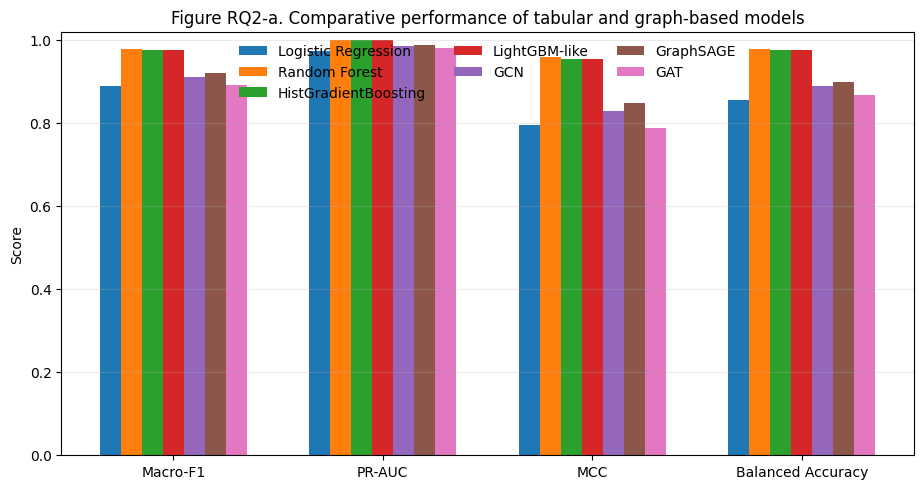

Saved:
outputs/rq2_figures/figure_rq2_a_comparative_performance.png
outputs/rq2_figures/figure_rq2_a_comparative_performance.pdf


In [7]:

plot_models = rq2_table_a["Model"].tolist()
metrics_to_plot = ["Macro-F1", "PR-AUC", "MCC", "Balanced Accuracy"]
plot_df = pd.concat([tabular_results, graph_results], ignore_index=True, sort=False)

fig, ax = plt.subplots(figsize=(11, 5.5))
idx = np.arange(len(metrics_to_plot))
width = 0.10

for i, model_name in enumerate(plot_models):
    vals = []
    for metric in metrics_to_plot:
        row = plot_df.loc[plot_df["Model"] == model_name, metric]
        vals.append(float(row.values[0]) if len(row) else np.nan)
    ax.bar(idx + (i - len(plot_models)/2) * width + width/2, vals, width=width, label=model_name)

ax.set_xticks(idx)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Score")
ax.set_title("Figure RQ2-a. Comparative performance of tabular and graph-based models")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=0.25)

fig_a_png = RQ2_FIG_DIR / "figure_rq2_a_comparative_performance.png"
fig_a_pdf = RQ2_FIG_DIR / "figure_rq2_a_comparative_performance.pdf"
fig.savefig(fig_a_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_a_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_a_png)
print(fig_a_pdf)



## 7. Run repeated-seed analysis for Table RQ2-b

This section estimates whether the graph-vs-tabular differences are stable across repeated seeds.

It always runs the **tabular repeated-seed benchmark**.
The graph repeated-seed part runs only if `torch-geometric` is available.


In [8]:

seed_rows = []

for seed in ROBUSTNESS_SEEDS:
    set_seed(seed)
    p = preprocess_split(df_work, seed)

    # Tabular: keep strongest two for comparison table
    tab_models = get_tabular_models(seed)
    keep_names = [n for n in tab_models.keys() if n in ["XGBoost", "HistGradientBoosting", "LightGBM-like"]]
    for model_name in keep_names:
        model = tab_models[model_name]
        model.fit(p["X_train"], p["y_train"])
        y_pred = model.predict(p["X_test"])
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(p["X_test"])[:, 1]
        else:
            raw = model.decision_function(p["X_test"]) if hasattr(model, "decision_function") else y_pred
            raw = np.asarray(raw).reshape(-1)
            y_prob = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
        met = compute_metrics(p["y_test"], y_pred, y_prob)
        seed_rows.append({
            "Seed": seed,
            "Model": model_name,
            "Macro-F1": met["Macro-F1"]
        })

    if PYG_AVAILABLE:
        gd = build_graph_data(p["X_train"], p["X_test"], p["y_train"], p["y_test"], k=5, metric="cosine")
        gmodels = {
            "GCN": GCNNet(gd.num_node_features, hidden=32),
            "GraphSAGE": SAGENet(gd.num_node_features, hidden=32),
            "GAT": GATNet(gd.num_node_features, hidden=16, heads=2)
        }
        for name, model in gmodels.items():
            met = train_gnn(model, gd, epochs=80, lr=0.01)
            seed_rows.append({
                "Seed": seed,
                "Model": name,
                "Macro-F1": met["Macro-F1"]
            })

seed_results = pd.DataFrame(seed_rows)
display(seed_results.head())


,Seed,Model,Macro-F1
0,42,HistGradientBoosting,0.977159
1,42,LightGBM-like,0.977159
2,42,GCN,0.900388
3,42,GraphSAGE,0.915653
4,42,GAT,0.885280


## 8. Build Table RQ2-b: statistical comparison across repeated seeds

In [9]:

pairs = []

def add_pair(name_a, name_b, interpretation):
    if name_a in seed_results["Model"].unique() and name_b in seed_results["Model"].unique():
        a = seed_results.loc[seed_results["Model"] == name_a, "Macro-F1"].sort_index().values
        b = seed_results.loc[seed_results["Model"] == name_b, "Macro-F1"].sort_index().values
        if len(a) == len(b) and len(a) > 0:
            diff = a - b
            try:
                stat, pval = wilcoxon(diff)
            except Exception:
                pval = np.nan
            effect = float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-9))
            pairs.append({
                "Model Pair": f"{name_a} vs {name_b}",
                "Mean Macro-F1 Difference": float(np.mean(diff)),
                "Std. Dev.": float(np.std(diff, ddof=1) if len(diff) > 1 else 0.0),
                "Wilcoxon p-value": float(pval) if not np.isnan(pval) else np.nan,
                "Effect Size": effect,
                "Interpretation": interpretation
            })

xgb_name = "XGBoost" if "XGBoost" in seed_results["Model"].unique() else "HistGradientBoosting"
add_pair(xgb_name, "GCN", "Tabular vs graph baseline")
add_pair(xgb_name, "GraphSAGE", "Tabular vs graph baseline")
add_pair(xgb_name, "GAT", "Tabular vs graph baseline")
add_pair("LightGBM-like", "GCN", "Strong tabular vs graph baseline")
add_pair("LightGBM-like", "GraphSAGE", "Strong tabular vs graph baseline")
add_pair("LightGBM-like", "GAT", "Strong tabular vs graph baseline")

rq2_table_b = pd.DataFrame(pairs)
table_b_path = RQ2_TABLE_DIR / "table_rq2_b_statistical_comparison.csv"
rq2_table_b.to_csv(table_b_path, index=False)

display(rq2_table_b)
print("Saved:", table_b_path)


,Model Pair,Mean Macro-F1 Difference,Std. Dev.,Wilcoxon p-value,Effect Size,Interpretation
0,HistGradientBoosting vs GCN,0.084521,0.006537,0.0625,12.929381,Tabular vs graph baseline
1,HistGradientBoosting vs GraphSAGE,0.063102,0.007048,0.0625,8.953034,Tabular vs graph baseline
2,HistGradientBoosting vs GAT,0.100374,0.008514,0.0625,11.788975,Tabular vs graph baseline
3,LightGBM-like vs GCN,0.084521,0.006537,0.0625,12.929381,Strong tabular vs graph baseline
4,LightGBM-like vs GraphSAGE,0.063102,0.007048,0.0625,8.953034,Strong tabular vs graph baseline
5,LightGBM-like vs GAT,0.100374,0.008514,0.0625,11.788975,Strong tabular vs graph baseline


Saved: outputs/rq2_tables/table_rq2_b_statistical_comparison.csv


## 9. Build Figure RQ2-b: sensitivity of graph models to graph-construction choices

,Graph Metric,k,Macro-F1,PR-AUC
0,cosine,3,0.915748,0.989677
1,cosine,5,0.916663,0.985351
2,cosine,10,0.913565,0.984603
3,euclidean,3,0.913437,0.986615
4,euclidean,5,0.920511,0.988116
5,euclidean,10,0.910748,0.987661


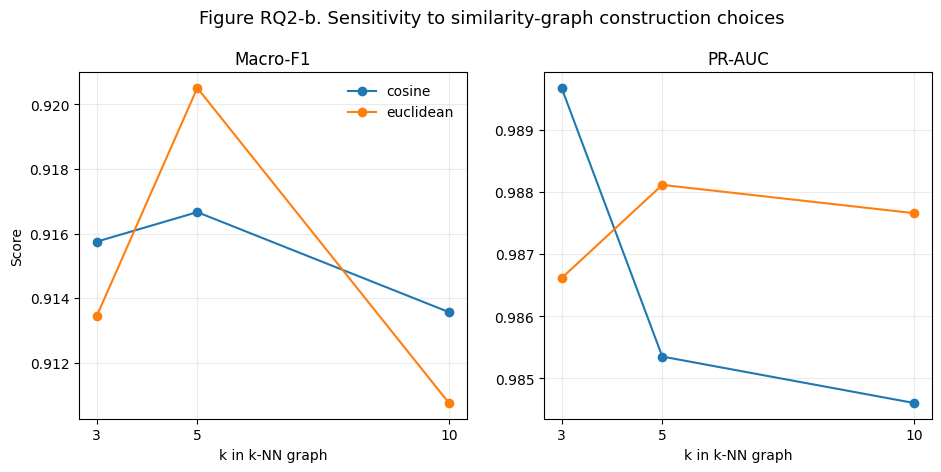

Saved:
outputs/rq2_figures/figure_rq2_b_graph_sensitivity.png
outputs/rq2_figures/figure_rq2_b_graph_sensitivity.pdf


In [10]:

if PYG_AVAILABLE:
    sensitivity_rows = []
    k_values = [3, 5, 10]
    metrics_graph = ["cosine", "euclidean"]

    for metric_name in metrics_graph:
        for k in k_values:
            gd = build_graph_data(pack["X_train"], pack["X_test"], pack["y_train"], pack["y_test"], k=k, metric=metric_name)
            # Use GraphSAGE as the main sensitivity reference for RQ2
            model = SAGENet(gd.num_node_features, hidden=32)
            met = train_gnn(model, gd, epochs=80, lr=0.01)
            sensitivity_rows.append({
                "Graph Metric": metric_name,
                "k": k,
                "Macro-F1": met["Macro-F1"],
                "PR-AUC": met["PR-AUC"]
            })

    sensitivity_df = pd.DataFrame(sensitivity_rows)
    display(sensitivity_df)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
    for metric_name, sub in sensitivity_df.groupby("Graph Metric"):
        axes[0].plot(sub["k"], sub["Macro-F1"], marker="o", label=metric_name)
        axes[1].plot(sub["k"], sub["PR-AUC"], marker="o", label=metric_name)

    axes[0].set_title("Macro-F1")
    axes[1].set_title("PR-AUC")
    for ax in axes:
        ax.set_xlabel("k in k-NN graph")
        ax.set_xticks(k_values)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("Score")
    axes[0].legend(frameon=False)

    fig.suptitle("Figure RQ2-b. Sensitivity to similarity-graph construction choices", fontsize=13, y=1.02)

    fig_b_png = RQ2_FIG_DIR / "figure_rq2_b_graph_sensitivity.png"
    fig_b_pdf = RQ2_FIG_DIR / "figure_rq2_b_graph_sensitivity.pdf"
    fig.savefig(fig_b_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_b_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved:")
    print(fig_b_png)
    print(fig_b_pdf)
else:
    sensitivity_df = pd.DataFrame(columns=["Graph Metric", "k", "Macro-F1", "PR-AUC"])
    print("Figure RQ2-b skipped because torch-geometric is not installed.")


## 10. Save a compact RQ2 summary JSON

In [11]:

summary = {
    "dataset_summary": dataset_summary,
    "table_rq2_a": str(table_a_path),
    "table_rq2_b": str(table_b_path),
    "figure_rq2_a": str(RQ2_FIG_DIR / "figure_rq2_a_comparative_performance.pdf"),
    "figure_rq2_b": str(RQ2_FIG_DIR / "figure_rq2_b_graph_sensitivity.pdf"),
    "xgboost_available": bool(XGB_AVAILABLE),
    "pyg_available": bool(PYG_AVAILABLE),
    "robustness_seeds": ROBUSTNESS_SEEDS
}

summary_path = RQ2_TABLE_DIR / "rq2_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)
summary


Saved summary to: outputs/rq2_tables/rq2_summary.json


{'dataset_summary': {'shape': (14368, 46),
  'label_distribution': {1: 10894, 0: 3474},
  'missingness': {'followers_count': 0.0,
   'friends_count': 0.0,
   'statuses_count': 0.0,
   'favourites_count': 0.0,
   'listed_count': 0.0,
   'default_profile': 0.686,
   'default_profile_image': 0.9946,
   'geo_enabled': 0.7611}},
 'table_rq2_a': 'outputs/rq2_tables/table_rq2_a_main_model_comparison.csv',
 'table_rq2_b': 'outputs/rq2_tables/table_rq2_b_statistical_comparison.csv',
 'figure_rq2_a': 'outputs/rq2_figures/figure_rq2_a_comparative_performance.pdf',
 'figure_rq2_b': 'outputs/rq2_figures/figure_rq2_b_graph_sensitivity.pdf',
 'xgboost_available': False,
 'pyg_available': True,
 'robustness_seeds': [42, 52, 62, 72, 82]}


## 11. What this notebook produces for RQ2

After running the notebook, you will have:

### Tables
- `table_rq2_a_main_model_comparison.csv`
- `table_rq2_b_statistical_comparison.csv`

### Figures
- `figure_rq2_a_comparative_performance.pdf`
- `figure_rq2_b_graph_sensitivity.pdf`

### Notes
- The **tabular RQ2 pipeline runs immediately**.
- The **graph sections require `torch-geometric`**.
- The notebook already includes an **XGBoost fallback**.
